In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import collections
import random

In [3]:
# --- 1. Wireless Environment Parameters ---
B_HZ = 1e6              # 1 MHz
N0_DBM_HZ = -174        # Noise density
P_TX_CLIENT_DBM = 24    # Uplink Power
P_TX_SERVER_DBM = 46    # Downlink Power (Server)
Q_BITS = 16             # 16-bit quantization
RADIUS_KM = 0.5         # 500m
DEVICE_GFLOPS = 2.0     # Average edge device speed (2 Billion operations/sec)

In [4]:
def plot_radar_map(r_km):
    """
    Plots 30 devices in a circular layout with index labels.
    Red triangle = Edge Server (Center)
    Blue dots = Edge Devices (Labeled 0-29)
    """
    # Generate random angles (theta) in radians
    theta = 2 * np.pi * np.random.rand(len(r_km)) 
    
    # Convert polar (r, theta) to Cartesian (x, y) for easier labeling
    x = r_km * np.cos(theta)
    y = r_km * np.sin(theta)
    
    plt.figure(figsize=(8, 8))
    
    # Plot the circular boundary (500m radius)
    circle = plt.Circle((0, 0), RADIUS_KM, color='gray', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)
    
    # Plot Edge Server at the center (0,0)
    plt.scatter(0, 0, c='red', marker='^', s=150, label='Edge Server', zorder=5)
    
    # Plot Edge Devices
    plt.scatter(x, y, c='skyblue', edgecolors='navy', s=80, alpha=0.8, label='Edge Devices')
    
    # Add Index Labels (0 to 29) for each device
    for i in range(len(r_km)):
        plt.annotate(f'{i}', (x[i], y[i]), xytext=(5, 5), 
                     textcoords='offset points', fontsize=9, fontweight='bold')

    plt.title(f"Device Distribution ({RADIUS_KM*1000}m Radius)")
    plt.xlabel("Distance (km)")
    plt.ylabel("Distance (km)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.axis('equal') # Keep the circle from looking like an oval
    plt.xlim(-RADIUS_KM - 0.1, RADIUS_KM + 0.1)
    plt.ylim(-RADIUS_KM - 0.1, RADIUS_KM + 0.1)
    plt.show()

In [5]:
# --- 2. Model Architectures ---

class SVMModel(nn.Module):
    def __init__(self):
        super(SVMModel, self).__init__()
        self.fc = nn.Linear(3072, 1)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, 10))
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))

In [6]:
# --- 3. Data Preparation ---

def get_datasets(task='CNN'):
    # Define a shared seed for reproducibility if needed, 
    # or remove it for different random splits each time.
    random.seed(42) 
    np.random.seed(42)

    if task == 'SVM':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
        train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        
        train_idx = [i for i, l in enumerate(train_set.targets) if l in [0, 1]]
        test_idx = [i for i, l in enumerate(test_set.targets) if l in [0, 1]]
        
        airplanes = [i for i in train_idx if train_set.targets[i] == 0][:15*330]
        autos = [i for i in train_idx if train_set.targets[i] == 1][:15*330]
        
        # Create the raw list of 30 Subsets
        all_subsets = [Subset(train_set, airplanes[i*330:(i+1)*330]) for i in range(15)] + \
                       [Subset(train_set, autos[i*330:(i+1)*330]) for i in range(15)]
        
        # RANDOMIZATION: Shuffle the list so 'Airplane devices' are spread 0-29
        random.shuffle(all_subsets)
        device_data = all_subsets
        
        return device_data, Subset(test_set, test_idx), SVMModel(), 0.0001

    else: # CNN Task (MNIST)
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
        
        # Pathological Non-IID: Sort by label to create shards
        indices = np.argsort(train_set.targets.numpy())
        shards = [indices[i*1000 : (i+1)*1000] for i in range(60)]
        
        # RANDOMIZATION: Shuffle the shards so Device 0 doesn't 
        # automatically get the 'lowest' labels (0 and 1)
        random.shuffle(shards)
        
        # Each device gets 2 random shards (each shard is likely 1 digit)
        device_data = [Subset(train_set, np.concatenate((shards[i*2], shards[i*2+1]))) for i in range(30)]
        
        return device_data, test_set, CNNModel(), 0.1
    
def observe_distribution(device_data, task='CNN'):
    # Determine how many classes to show
    num_labels = 10 if task == 'CNN' else 2
    distribution_matrix = np.zeros((30, num_labels))

    for i in range(30):
        subset = device_data[i]
        # Robustly handle different dataset target formats
        targets = subset.dataset.targets
        subset_labels = [int(targets[idx]) for idx in subset.indices]
        
        counts = collections.Counter(subset_labels)
        for label, count in counts.items():
            # For SVM, only record if label is 0 or 1
            if label < num_labels:
                distribution_matrix[i, label] = count

    # Plotting
    plt.figure(figsize=(8, 8)) # Narrower figure for 2 columns
    im = plt.imshow(distribution_matrix, cmap='YlGnBu', aspect='auto')
    
    plt.colorbar(im, label='Number of Samples')
    plt.title(f'Non-IID Heatmap: {task} Task', fontsize=14)
    plt.xlabel('Class Label', fontsize=12)
    plt.ylabel('Device Index', fontsize=12)
    
    # Set x-ticks specifically to the number of labels
    plt.xticks(range(num_labels))
    # If SVM, label them appropriately
    if task == 'SVM':
        plt.gca().set_xticklabels(['0 (Airplane)', '1 (Auto)'])
    
    plt.yticks(range(0, 30, 2))
    plt.tight_layout()
    plt.show()

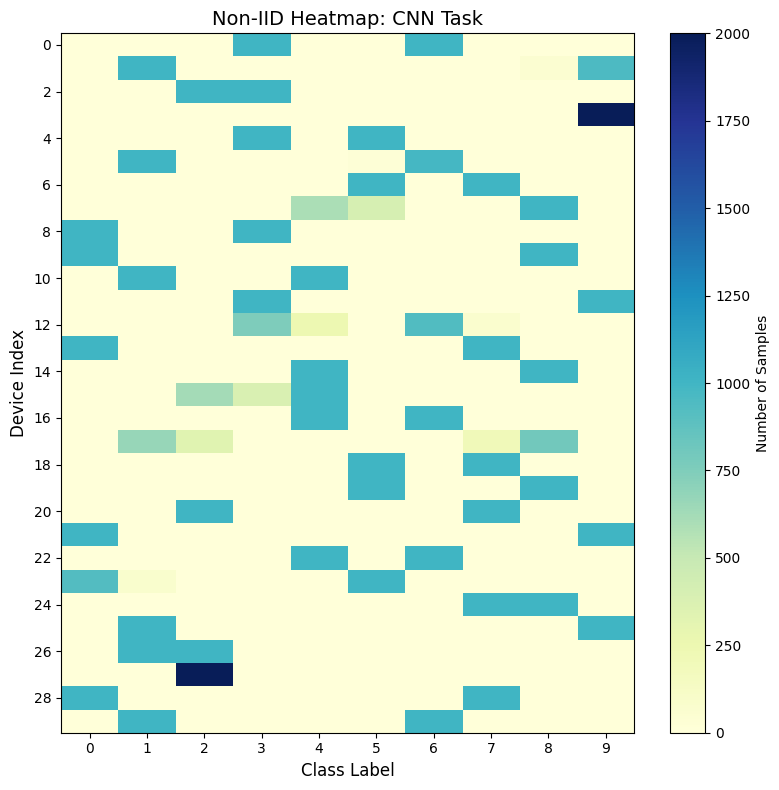

In [7]:
device_data_svm, _, _, _ = get_datasets(task='CNN')
observe_distribution(device_data_svm, task='CNN')

In [8]:
def get_optimal_probabilities(n_k_list, grad_norms, T_u_list, rho):
    """
    Implements Theorem 1 - Importance- and channel-aware scheduling policy.
    """
    n_total = sum(n_k_list)
    grad_norms = np.array(grad_norms) + 1e-12 
    T_u_list = np.array(T_u_list)
    num_devices = len(n_k_list)

    floor_value = 0.0001 # Each device gets at least 1% chance
    total_floor = num_devices * floor_value
    remaining_budget = 1.0 - total_floor

    def apply_gaussian_top3(values, reverse=False):
        # 1. Start everyone with the 1% floor
        p = np.full(num_devices, floor_value)
        
        # 2. Identify the Top 3
        sorted_indices = np.argsort(values)
        if not reverse:
            sorted_indices = sorted_indices[::-1]
            
        # 3. Distribute the remaining 40% budget using Gaussian weights
        # Weights: Rank1 (1.0), Rank2 (0.606), Rank3 (0.135) -> Sum = 1.741
        raw_weights = np.array([1.0, 0.606, 0.135])
        normalized_weights = raw_weights / np.sum(raw_weights) # Scale to sum to 1.0
        
        # Add the budgeted share to the floor
        p[sorted_indices[0]] += normalized_weights[0] * remaining_budget
        p[sorted_indices[1]] += normalized_weights[1] * remaining_budget
        p[sorted_indices[2]] += normalized_weights[2] * remaining_budget
        
        return p

    # 1. New Behavior for rho = 0 (Channel-aware: Top 3 Fastest)
    if rho == 0:
        return apply_gaussian_top3(T_u_list, reverse=True)

    # 2. New Behavior for rho = 1 (Importance-aware: Top 3 Most Informative)
    if rho == 1:
        # Importance includes data weight n_k/n
        importance = (np.array(n_k_list) / n_total) * grad_norms
        return apply_gaussian_top3(importance, reverse=False)

    # 3. Proposed Policy (Intermediate rho)
    def compute_p_star(lam):
        denom = (1 - rho) * T_u_list + lam
        p = (np.array(n_k_list) / n_total) * grad_norms * np.sqrt(rho / np.maximum(denom, 1e-15))
        return p

    low = -np.min((1 - rho) * T_u_list) + 1e-12
    high = 1e6 
    
    for _ in range(100):
        mid = (low + high) / 2
        if np.sum(compute_p_star(mid)) > 1: low = mid
        else: high = mid

    lambda_star  = high
    final_p_raw = compute_p_star(lambda_star)
    return final_p_raw / np.sum(final_p_raw)

In [9]:
def run_importance_aware_fl(task='SVM', training_time=10, rho=5e-6, r_km= RADIUS_KM * np.sqrt(np.random.rand(30))):
    device_data, test_set, global_model, lr = get_datasets(task)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)
    n_k_list = [len(d) for d in device_data]
    n_total = sum(n_k_list)
    lmbda = 0.01 
    selection_counts = np.zeros(30)
    history = {'acc': [], 'time': []}
    cumulative_time = 0

    print(f"\n--- Simulation: {task} | 30 Clients | Training Time: {training_time}s ---")

    while cumulative_time < training_time:
        # Communication Model
        path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
        
        noise_up_w = 10**(((N0_DBM_HZ + 10 * np.log10(B_HZ)) - 30) / 10)
        p_rx_up_w = 10**(((P_TX_CLIENT_DBM - path_loss_db) - 30) / 10)
        gamma_up = p_rx_up_w / noise_up_w
        
        noise_down_w = 10**(((N0_DBM_HZ + 10 * np.log10(B_HZ)) - 30) / 10)
        p_rx_down_w = 10**(((P_TX_SERVER_DBM - path_loss_db) - 30) / 10)
        gamma_down_min = np.min(p_rx_down_w / noise_down_w) 
        
        num_params = sum(p.numel() for p in global_model.parameters())
        payload_bits = num_params * Q_BITS
        T_u_list = payload_bits / (B_HZ * np.log2(1 + gamma_up))

        # Importance Evaluation
        grad_norms = []
        client_gradients = []
        for i in range(30):
            # Step 1: Global Model Broadcast
            local_model = type(global_model)()
            local_model.load_state_dict(global_model.state_dict())
            loader = DataLoader(device_data[i], batch_size=len(device_data[i]))
            data, target = next(iter(loader))
            local_model.zero_grad()

            # Step 2: Local Gradient Calculation
            output = local_model(data).squeeze()
            if task == 'SVM':
                target_svm = (target.float() * 2) - 1 
                loss = 0.5 * torch.mean(torch.clamp(1 - target_svm * output, min=0)) + (lmbda / 2.0) * sum(p.pow(2).sum() for p in local_model.parameters())
            else:
                target_oh = torch.nn.functional.one_hot(target, num_classes=10).float()
                loss = 0.5 * torch.nn.functional.mse_loss(output, target_oh, reduction='mean')

            # Step 3: Importance Indicator Report
            loss.backward()
            grads = [p.grad.detach().clone() for p in local_model.parameters()]
            grad_norms.append(torch.norm(torch.cat([g.view(-1) for g in grads])).item())
            client_gradients.append(grads)

        # Step 4: Device Selection and Resource Allocation
        p_star = get_optimal_probabilities(n_k_list, grad_norms, T_u_list, rho)
        print(f"Probability Policy: [Max: {100 * np.max(p_star):.2f}% - (Device {np.argmax(p_star)}) | "
        f"Min: {100 * np.min(p_star):.2f}% | Std: {100 * np.std(p_star):.2f}% | Sum: {100 * np.sum(p_star):.2f}% ]")
        selected_idx = np.random.choice(range(30), p=p_star)
        selection_counts[selected_idx] += 1

        # Step 5: Local Gradient Upload (Simulate latency)
        t_broadcast = payload_bits / (B_HZ * np.log2(1 + gamma_down_min)) 
        t_comp_max = (max(n_k_list) * (6000 if task=='SVM' else 15e6)) / (DEVICE_GFLOPS * 1e9)
        cumulative_time += (t_broadcast + t_comp_max + T_u_list[selected_idx])

        # Step 6: Global Model Update
        with torch.no_grad():
            if rho == 0 or rho == 1:
                scale = n_k_list[selected_idx] / n_total
            else:
                # Standard Theorem 1 Unbiased Estimator
                scale = n_k_list[selected_idx] / (n_total) # * p_star[selected_idx]) IGNORE
            for p_global, g_local in zip(global_model.parameters(), client_gradients[selected_idx]):
                p_global -= lr * (scale * g_local)

        # Evaluation
        global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                output = global_model(data)
                pred = torch.sign(output.squeeze()) if task == 'SVM' else output.argmax(1)
                labels = (target.float()*2-1) if task == 'SVM' else target
                correct += (pred == labels).sum().item()
                total += target.size(0)
        
        acc = 100. * correct / total
        history['acc'].append(acc)
        history['time'].append(cumulative_time)
        print(f"Time: {cumulative_time:.3f}s / {training_time}s | Acc: {acc:.2f}%")

    return history, selection_counts

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


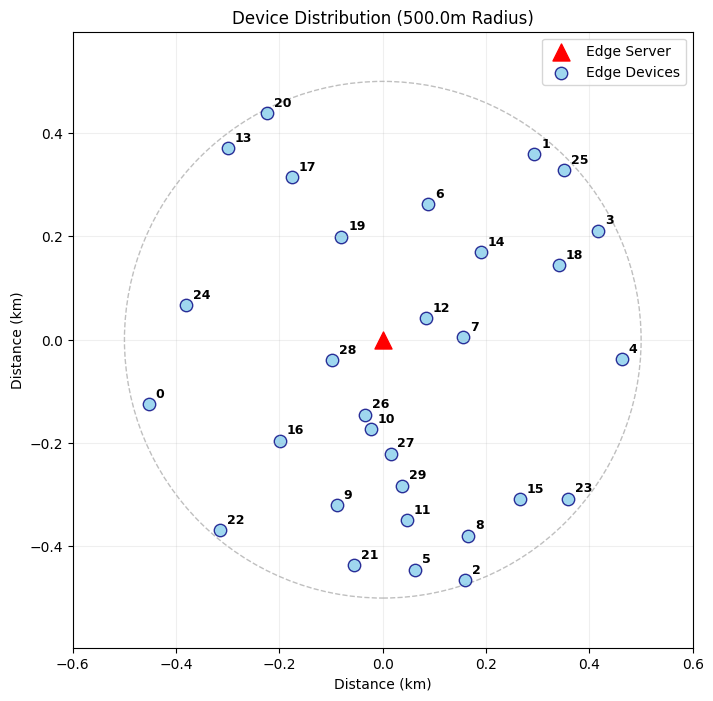

In [10]:
# Force 5 devices to be at the cell edge (450m - 500m) 
# and 25 devices to be distributed normally.
r_km = RADIUS_KM * np.sqrt(np.random.rand(30))
r_km[:5] = 0.45 + (np.random.rand(5) * 0.05)
plot_radar_map(r_km)

In [11]:
def run_full_comparison(task='SVM', max_sim_time=0.1):
    """Modified comparison loop to use max_sim_time instead of rounds."""
    if task == 'SVM':
        rhos = {0: 'Channel-aware', 1: 'Importance-aware', 5e-4: 'Proposed (5e-4)', 5e-5: 'Proposed (5e-5)', 5e-6: 'Proposed (5e-6)'}
        time_scale = 1
    else:
        rhos = {0: 'Channel-aware', 1: 'Importance-aware', 5e-3: 'Proposed (5e-3)', 5e-1: 'Proposed (5e-1)', 9e-1: 'Proposed (9e-1)'}
        time_scale = 60

    training_results = {}
    selection_results = {}
    # Force 5 devices to be at the cell edge (450m - 500m) 
    # and 25 devices to be distributed normally.
    r_km = RADIUS_KM * np.sqrt(np.random.rand(30))
    r_km[:5] = 0.45 + (np.random.rand(5) * 0.05)
    plot_radar_map(r_km)

    for rho, label in rhos.items():
        print(f"\n>>> Running {label} Policy, rho={rho} <<<")
        history, sel_counts = run_importance_aware_fl(task=task, training_time=max_sim_time, rho=rho, r_km=r_km)
        training_results[label] = history
        selection_results[label] = sel_counts

    # --- Plot Comparison ---
    plt.figure(figsize=(10, 6))
    for label, hist in training_results.items():
        plt.plot(np.array(hist['time']) / time_scale, hist['acc'], label=label)
    plt.xlabel(f"Training Time ({'Seconds' if time_scale==1 else 'Minutes'})")
    plt.ylabel("Accuracy")
    plt.title(f"Performance Comparison: {task}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Selection Counts ---
    fig, axes = plt.subplots(len(rhos), 1, figsize=(12, 3 * len(rhos)))
    if len(rhos) == 1: axes = [axes] 

    for ax, (label, sel) in zip(axes, selection_results.items()):
        # Plotting the bars
        ax.bar(range(30), sel, color='teal', edgecolor='black', alpha=0.7)
    
        # 2. Set the Title and Labels
        ax.set_title(f"Selection Frequency: {label}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Count")
    
        # 3. Force the ticks and labels on EVERY subplot
        ax.set_xticks(range(30))
        ax.tick_params(labelbottom=True) # Forces labels to appear even if sharing axes
    
        # 4. Styling the grid
        ax.grid(axis='y', linestyle='--', alpha=0.4)
    
        # 5. Optional: Set Y-axis to integers only (since counts are whole numbers)
        ax.yaxis.get_major_locator().set_params(integer=True)

    plt.xlabel("Device Index")
    plt.tight_layout()
    plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


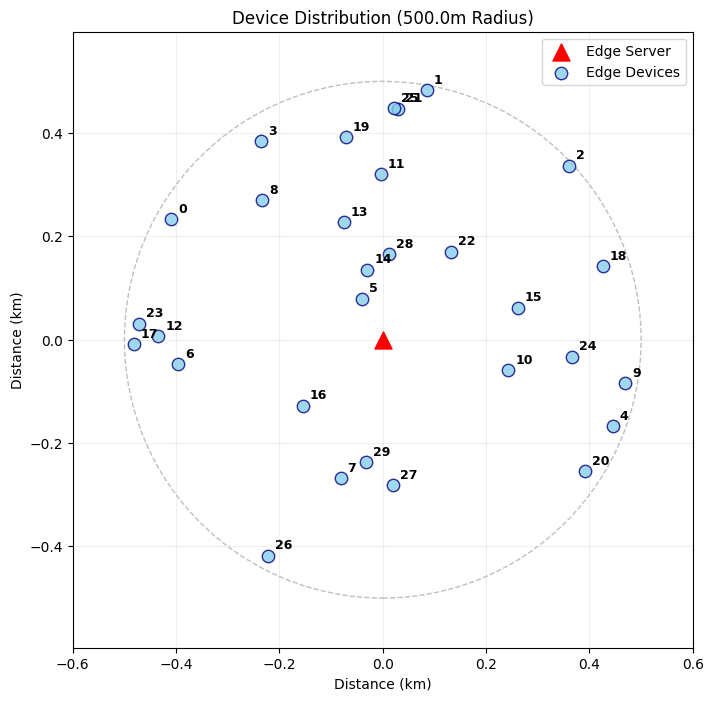


>>> Running Channel-aware Policy, rho=0 <<<

--- Simulation: CNN | 30 Clients | Training Time: 12000s ---
Probability Policy: [Max: 57.28% - (Device 5) | Min: 0.01% | Std: 11.85% | Sum: 100.00% ]
Time: 16.212s / 12000s | Acc: 7.71%
Probability Policy: [Max: 57.28% - (Device 5) | Min: 0.01% | Std: 11.85% | Sum: 100.00% ]
Time: 32.572s / 12000s | Acc: 7.84%
Probability Policy: [Max: 57.28% - (Device 5) | Min: 0.01% | Std: 11.85% | Sum: 100.00% ]
Time: 48.882s / 12000s | Acc: 7.85%
Probability Policy: [Max: 57.28% - (Device 5) | Min: 0.01% | Std: 11.85% | Sum: 100.00% ]
Time: 65.192s / 12000s | Acc: 7.79%
Probability Policy: [Max: 57.28% - (Device 5) | Min: 0.01% | Std: 11.85% | Sum: 100.00% ]
Time: 81.404s / 12000s | Acc: 7.81%
Probability Policy: [Max: 57.28% - (Device 5) | Min: 0.01% | Std: 11.85% | Sum: 100.00% ]
Time: 97.616s / 12000s | Acc: 7.86%
Probability Policy: [Max: 57.28% - (Device 5) | Min: 0.01% | Std: 11.85% | Sum: 100.00% ]
Time: 113.828s / 12000s | Acc: 7.86%
Probabilit

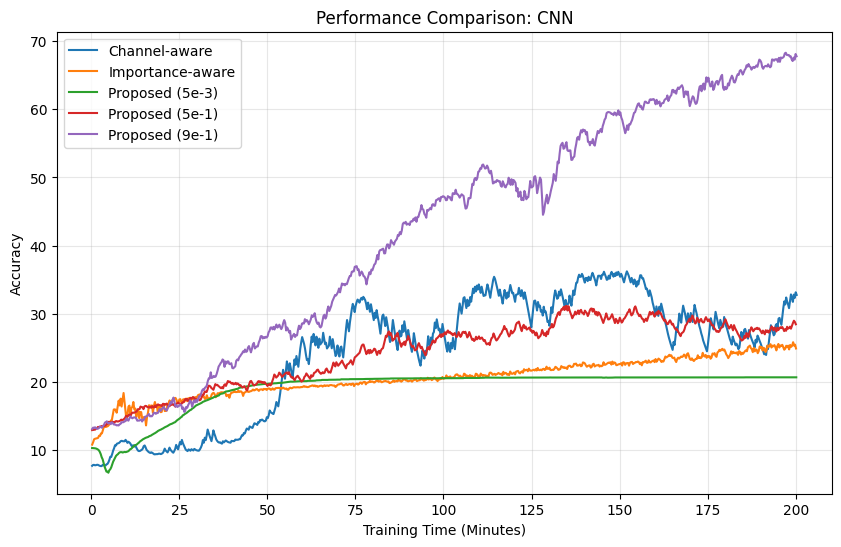

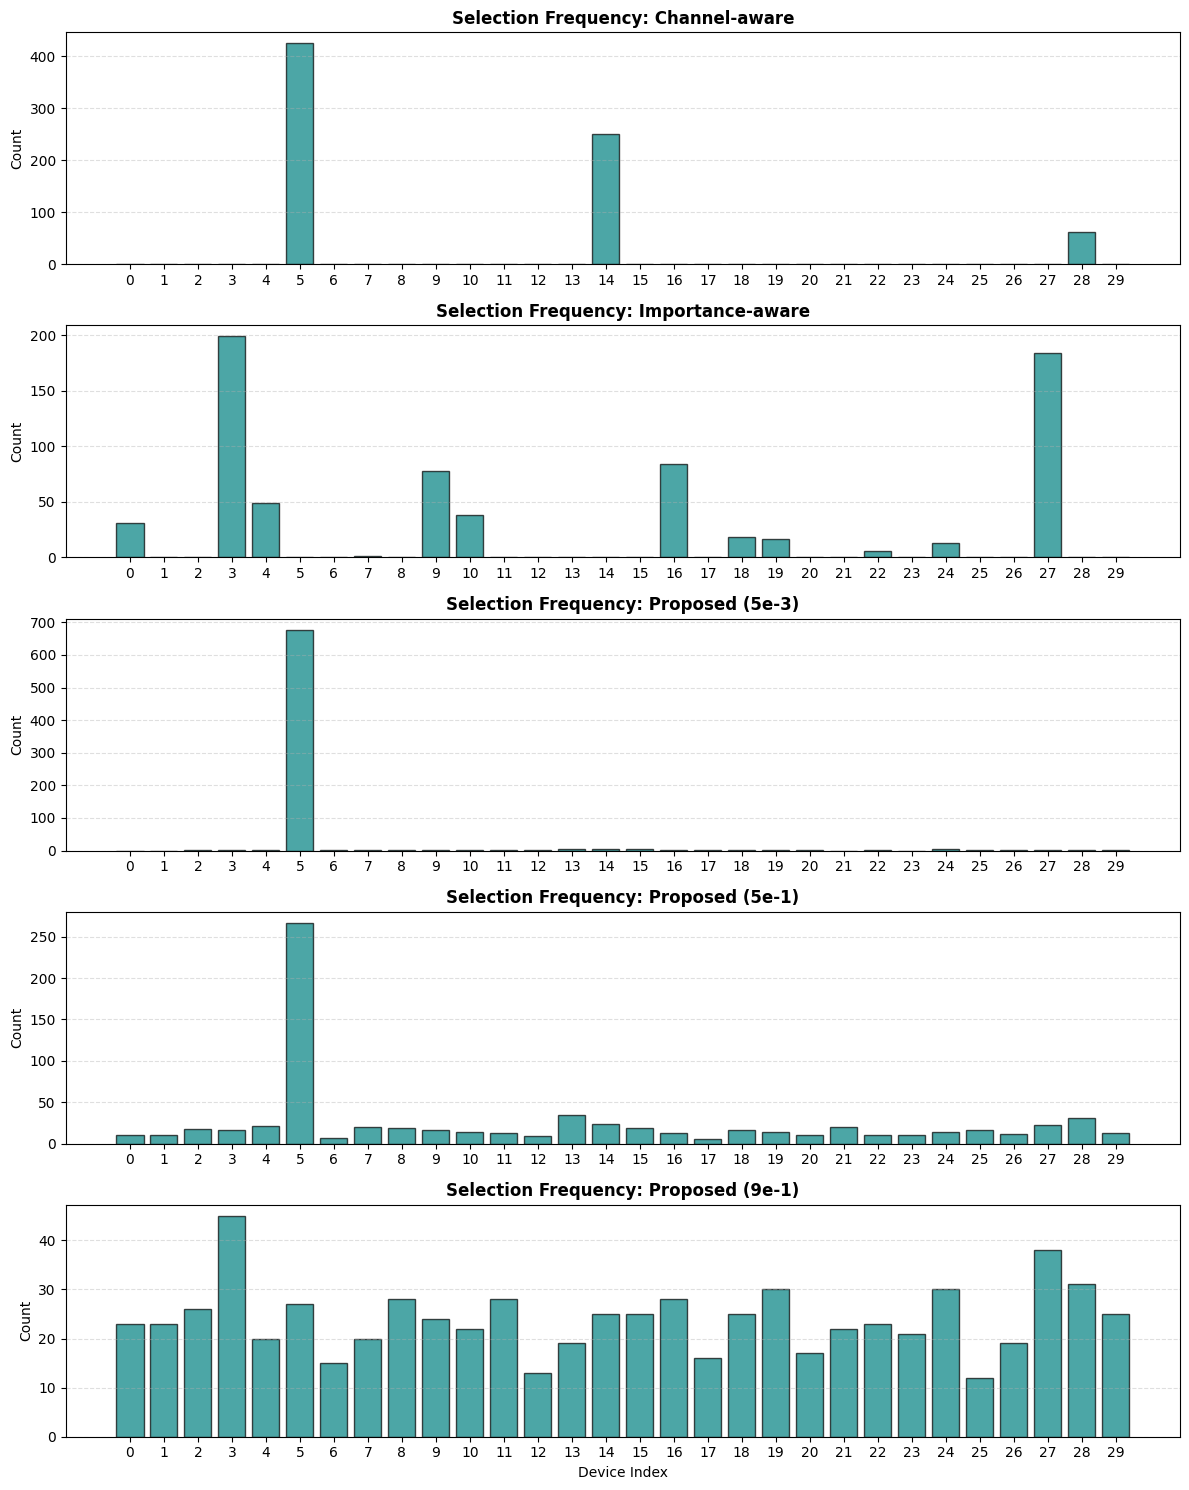

In [12]:
run_full_comparison(task='CNN', max_sim_time=12000)